In [21]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

# Set visualization styles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [22]:
# Load the dataset verbatim as requested
df = pd.read_csv("data/processed_esg_financial_data.csv")

# Define target
target = 'growth_rate'

# Strategic Feature Selection: Combining ESG constraints with Financial Baseline
features = [
    'esg_environmental',
    'esg_social',
    'esg_governance',
    
    'revenue',
    'profit_margin',
    'market_cap',
    
    # (from EDA)
    'growth_rate_lag1',
    'revenue_lag1',
    'profit_margin_lag1',
    'revenue_growth',
    'profit_trend',
    'year_normalized'
]

# Drop rows with missing values in our specific feature set
df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (Beneficial for regularized models and feature importance consistency)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (8000, 12)
Testing data shape: (2000, 12)


In [23]:
def evaluate(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"\\n--- {model_name} Performance ---")
    print(f"R2 Score: {r2:.4f}")
    print(f"MAE:      {mae:.4f}")
    print(f"RMSE:     {rmse:.4f}")
    return r2, mae, rmse

In [24]:
df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

In [25]:
df_sorted = df.sort_values('year')

train = df_sorted[df_sorted['year'] <= 2021]
test  = df_sorted[df_sorted['year'] > 2021]

# Now select only required columns
train = train[features + [target]].dropna()
test  = test[features + [target]].dropna()

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Evaluation
evaluate(y_test, y_pred, "Linear Regression")

\n--- Linear Regression Performance ---
R2 Score: 0.9739
MAE:      0.0032
RMSE:     0.0204


(0.9738907344425841, 0.003239440128028568, np.float64(0.020437732047189884))

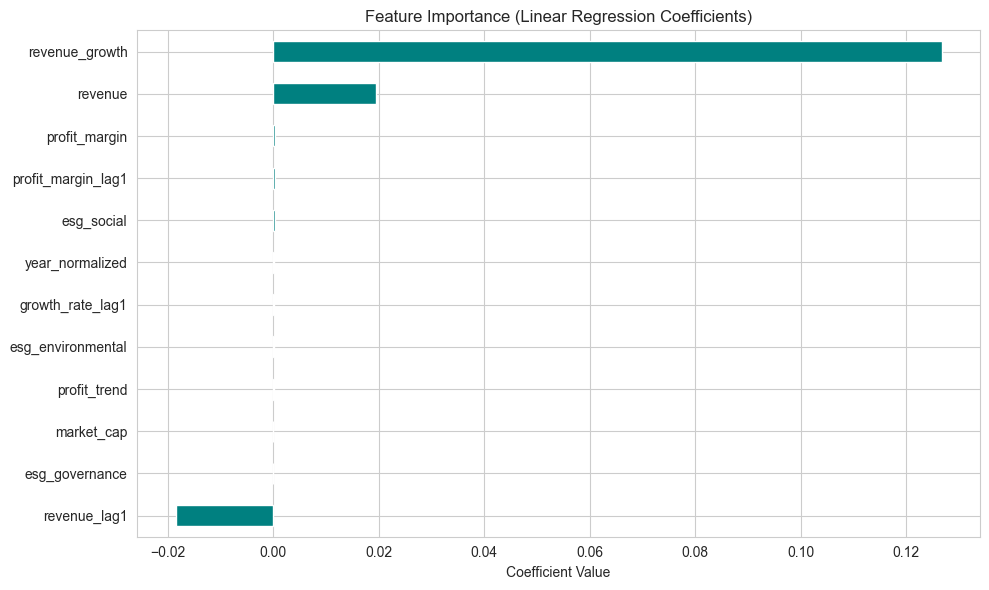

In [28]:
coef_df = pd.Series(model.coef_, index=features).sort_values()

plt.figure(figsize=(10, 6))
coef_df.plot(kind='barh', color='teal')
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

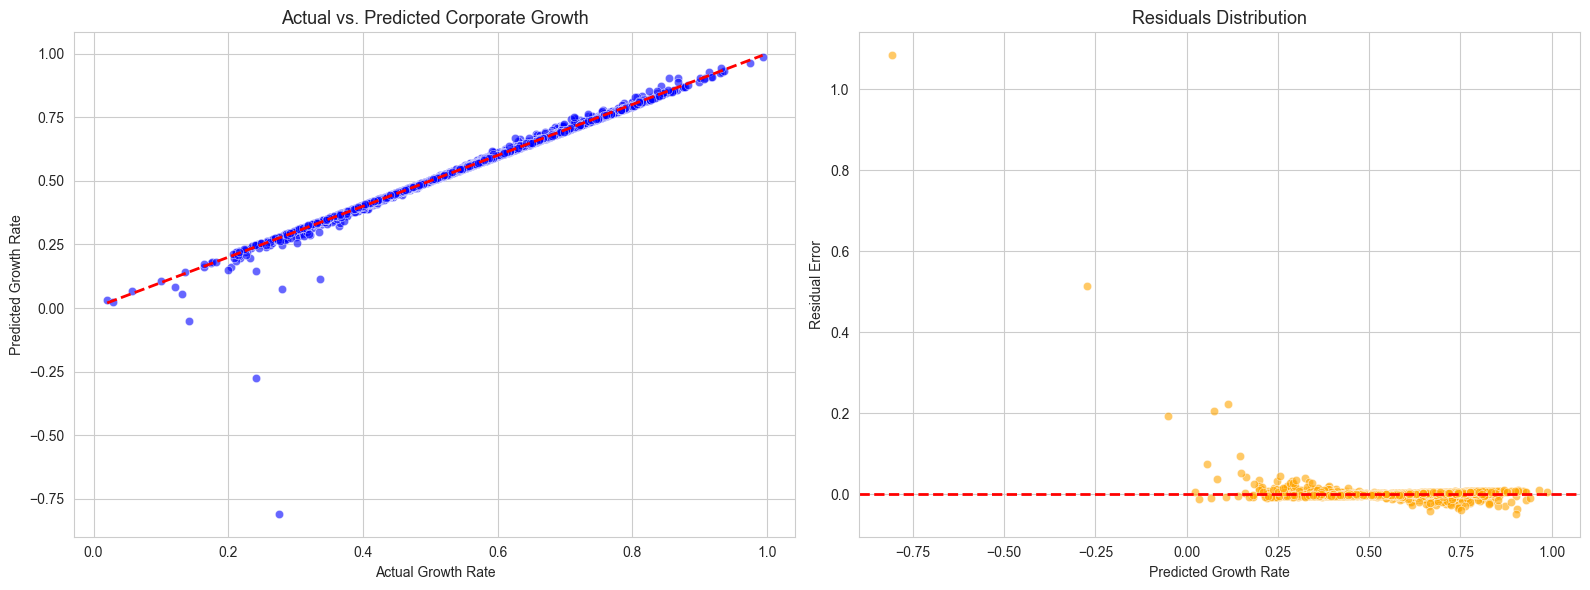

In [29]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], alpha=0.6, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title("Actual vs. Predicted Corporate Growth", fontsize=13)
axes[0].set_xlabel("Actual Growth Rate")
axes[0].set_ylabel("Predicted Growth Rate")

# Residual Plot
sns.scatterplot(x=y_pred, y=residuals, ax=axes[1], alpha=0.6, color='orange')
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_title("Residuals Distribution", fontsize=13)
axes[1].set_xlabel("Predicted Growth Rate")
axes[1].set_ylabel("Residual Error")

plt.tight_layout()
plt.show()

In [32]:
import joblib

# Save the full pipeline elements
artifact_payload = {
    "model": model,
    "scaler": scaler,
    "features": features
}

joblib.dump(artifact_payload, "model.pkl")
print("Linear Regression pipeline saved successfully to 'model.pkl'")

Linear Regression pipeline saved successfully to 'model.pkl'


In [33]:
print(df[['growth_rate', 'growth_rate_lag1']].corr())

                  growth_rate  growth_rate_lag1
growth_rate          1.000000          0.353265
growth_rate_lag1     0.353265          1.000000
